## Now m and b both variable affecting loss function
1. init random values for m and b (m = 1, b = 0)
2. epochs = 100, lr = 0.01
   for i in epochs:
       b = b-n.slope
       m = m-n.slope
3. loss = sum((actual(yi) - pred(yi)^2)) = sum((yi - m.xi - b)^2)
   now loss is function of both m and b so partially differentiate it with respect to both variables L(m, b)
4. pd(L)/pd(m) and pd(L)/pd(b) , L = sum((yi - m - b)^2)
5. then compare them to zero to minimize

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

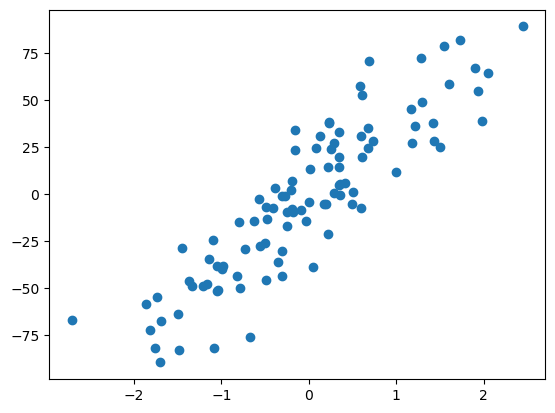

In [6]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=15)
plt.scatter(X,y)

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print(lr.coef_)
print(lr.intercept_)

[35.84106417]
-1.6551054965296115


In [44]:
np.mean(cross_val_score(lr, X, y, scoring='r2', cv=10))

0.7624771870249778

In [45]:
class GDRegressor:
    def __init__(self, lr, epochs):
        self.lr = lr
        self.epochs = epochs
        self.m = 100
        self.b = 120

    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slops_m = -2*np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            loss_slope_b = -2*np.sum(y - self.m*X.ravel() - self.b)
            self.m = self.m - (self.lr*loss_slops_m)
            self.b = self.b - (self.lr*loss_slope_b)
            print(self.m, self.b)

    def predict(self, X):
        return self.m*X + self.b

In [48]:
model = GDRegressor(0.001, 60)
model.fit(X_train, y_train)

90.84036435596705 100.54821728679711
82.98797866074176 84.20685898797596
76.25634200599728 70.47852277073558
70.4855500353352 58.94535278705429
65.53850380861189 49.256317639329936
61.29765878272591 41.11652310133206
57.66223700457463 34.278234143343035
54.545836554620074 28.533332866921555
51.8743816663581 23.70698268445201
49.58436499899595 19.65230581352386
47.62134044747149 16.24591201512036
45.93863079833233 13.384142427504933
44.49621962156917 10.979914124140377
43.25980114706959 8.960069317224027
42.199965612718195 7.263148495635573
41.291500777503465 5.837519695313149
40.51279304296286 4.639806944468617
39.84531398481314 3.6335700359036176
39.27318011935774 2.7881954314417277
38.78277546400676 2.077964532216111
38.36242793896616 1.4812709490326723
38.002131933003845 0.9799629437347099
37.6933104503351 0.5587910235872507
37.428611193952996 0.204943872239003
37.20173174534852 -0.092341509696162
37.00726969054862 -0.34210732206626243
36.840594134072454 -0.5519501102674773
36.69773

In [51]:
y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))

0.7851499665989365


In [52]:
# Effect of loss function on concave and convex funcions
# Gradient descent can stuck in local minima
# saddle point changes (like plateau_)

In [ ]:
# Explore contour plot